In [29]:
# Data handling
import pandas as pd          # Data loading and manipulation
import numpy as np           # Numerical operations

# Train-test split and hyperparameter tuning
from sklearn.model_selection import train_test_split, GridSearchCV

# Machine learning models
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

# Model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)

# Feature scaling
from sklearn.preprocessing import StandardScaler  # Normalize numerical features if required

# Handling class imbalance
from imblearn.combine import SMOTETomek  # Over- and under-sampling technique
from collections import Counter         # Count class distribution

# Visualization
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns            # Statistical plots

# Timing execution
import time  # Measure training and execution time

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Model persistence
import joblib  # Save and load trained models


In [31]:
# Load the reduced churn dataset
df = pd.read_csv("TelcoChurn_Top25_XGB.csv")  # Load dataset with top 25 features

print("Data loaded. Shape:", df.shape)  # Display dataset dimensions
df.head()  # Preview first few rows


Data loaded. Shape: (7032, 26)


,Contract_Payment_Month-to-month_Electronic check,InternetService_Fiber optic,Contract_Two year,OnlineSecurity_No internet service,Contract_One year,OnlineBackup_No internet service,InternetService_No,DeviceProtection_No internet service,StreamingMovies_Yes,tenure,...,TotalCharges,MultipleLines_Yes,MonthlyCharges,Contract_Payment_Month-to-month_Credit card (automatic),AvgChargesPerMonth,StreamingTV_Yes,OnlineBackup_Yes,MultipleLines_No phone service,SeniorCitizen,Churn
0,1,0,0,0,0,0,0,0,0,-1.280248,...,-0.994194,0,-1.161694,0,-1.157889,0,1,1,-0.440327,0
1,0,0,0,0,1,0,0,0,0,0.064303,...,-0.173740,0,-0.260878,0,-0.305658,0,0,0,-0.440327,0
2,0,0,0,0,0,0,0,0,0,-1.239504,...,-0.959649,0,-0.363923,0,-0.355305,0,1,0,-0.440327,1
3,0,0,0,0,1,0,0,0,0,0.512486,...,-0.195248,0,-0.747850,0,-0.791614,0,0,1,-0.440327,0
4,1,1,0,0,0,0,0,0,0,-1.239504,...,-0.940457,0,0.196178,0,0.365282,0,0,0,-0.440327,1


In [33]:
# Prepare features and target variable
X = df.drop(columns=["Churn"])  # Feature matrix
y = df["Churn"]                 # Target variable

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% data for testing
    random_state=42,      # Reproducibility
    stratify=y            # Preserve churn class distribution
)

print("Train shape:", X_train.shape)  # Training data size
print("Test shape:", X_test.shape)    # Testing data size

Train shape: (5625, 25)
Test shape: (1407, 25)


In [35]:
# Store evaluation metrics for all trained models
model_results = []  # Global list to collect model performance results

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best LR Params: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
LR Training Time: 1.521 sec
Best Threshold (LR): 0.4299999999999998
Best F1 at Threshold: 0.6307692307692307

--- Logistic Regression Evaluation ---
Accuracy: 0.7953091684434968
Recall: 0.6577540106951871
Precision: 0.6059113300492611
F1 Score: 0.6307692307692307
ROC-AUC: 0.8371184080426152

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1033
           1       0.61      0.66      0.63       374

    accuracy                           0.80      1407
   macro avg       0.74      0.75      0.74      1407
weighted avg       0.80      0.80      0.80      1407



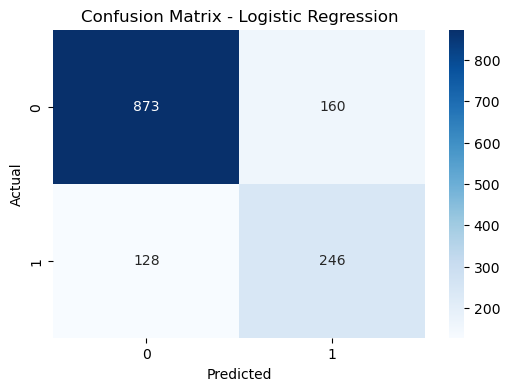

Saved model: LogisticRegression_BestModel.sav


In [37]:
# Logistic Regression with hyperparameter tuning, threshold optimization, evaluation, and saving

# Define hyperparameter search space for Logistic Regression
lr_param_grid = {
    "penalty": ["l1", "l2"],        # Regularization type
    "C": [0.01, 0.1, 1, 10],        # Regularization strength (smaller C = stronger regularization)
    "solver": ["liblinear"]         # Solver that supports both L1 and L2
}

# Perform GridSearchCV to find the best LR hyperparameters
lr_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=500),  # Increase iterations to help convergence
    param_grid=lr_param_grid,                   # Parameters to try
    scoring="roc_auc",                          # Optimize based on ROC-AUC
    cv=5,                                       # 5-fold cross-validation
    n_jobs=-1,                                  # Use all CPU cores
    verbose=1                                   # Show progress
)

# Train the model and record training time
start_lr = time.time()
lr_grid.fit(X_train, y_train)                   # Fit GridSearch on training data
end_lr = time.time()

print("Best LR Params:", lr_grid.best_params_)  # Best hyperparameter combination
print("LR Training Time:", round(end_lr - start_lr, 3), "sec")  # Training duration

# Extract the best Logistic Regression model found by GridSearchCV
lr_best = lr_grid.best_estimator_

# Predict churn probabilities (needed for threshold tuning)
y_prob_lr = lr_best.predict_proba(X_test)[:, 1]  # Probability of class 1 (churn)

# Compute ROC curve values for later plotting/analysis
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)  # False positive rate and true positive rate

# Automatically find the threshold that gives the best F1-score
thresholds = np.arange(0.1, 0.91, 0.01)  # Test thresholds from 0.10 to 0.90

best_f1 = 0
best_threshold = 0.5  # Default threshold

for t in thresholds:
    y_pred_t = (y_prob_lr >= t).astype(int)  # Convert probabilities to class labels using threshold t
    f1 = f1_score(y_test, y_pred_t)          # Compute F1-score
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold (LR):", best_threshold)  # Threshold with highest F1-score
print("Best F1 at Threshold:", best_f1)        # Best F1-score achieved

# Make final predictions using the best threshold
y_pred_lr = (y_prob_lr >= best_threshold).astype(int)  # Final churn predictions

# Print evaluation metrics for Logistic Regression
print("\n--- Logistic Regression Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))           # Overall correctness
print("Recall:", recall_score(y_test, y_pred_lr))               # Ability to catch churners
print("Precision:", precision_score(y_test, y_pred_lr))         # Correctness of churn predictions
print("F1 Score:", f1_score(y_test, y_pred_lr))                 # Balance of precision and recall
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))             # Ranking quality using probabilities

# Show detailed classification metrics per class
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))  # Precision/recall/F1 for each class

# Plot confusion matrix to visualize prediction outcomes
cm = confusion_matrix(y_test, y_pred_lr)  # Compute confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")  # Heatmap display
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save the best trained Logistic Regression model to disk
joblib.dump(lr_best, "LogisticRegression_BestModel.sav")  # Save model file
print("Saved model: LogisticRegression_BestModel.sav")

# Store Logistic Regression results for later model comparison
model_results.append({
    "model": "Logistic Regression",                       # Model name
    "roc_auc": roc_auc_score(y_test, y_prob_lr),          # ROC-AUC score
    "accuracy": accuracy_score(y_test, y_pred_lr),        # Accuracy score
    "recall": recall_score(y_test, y_pred_lr),            # Recall score
    "precision": precision_score(y_test, y_pred_lr),      # Precision score
    "f1": f1_score(y_test, y_pred_lr),                    # F1-score
    "best_threshold": best_threshold,                     # Best threshold used
    "train_time_sec": round(end_lr - start_lr, 4),        # Training time in seconds
    "fpr": fpr_lr,                                        # ROC curve FPR values
    "tpr": tpr_lr                                         # ROC curve TPR values
})


Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best RF Params: {'bootstrap': True, 'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
RF Training Time: 7.66 sec
Best Threshold (RF): 0.3599999999999999
Best F1 at Threshold: 0.6338535414165666

--- Random Forest Evaluation ---
Accuracy: 0.783226723525231
Recall: 0.7058823529411765
Precision: 0.5751633986928104
F1 Score: 0.6338535414165666
ROC-AUC: 0.8390894595979728

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.81      0.85      1033
           1       0.58      0.71      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.76      0.74      1407
weighted avg       0.80      0.78      0.79      1407



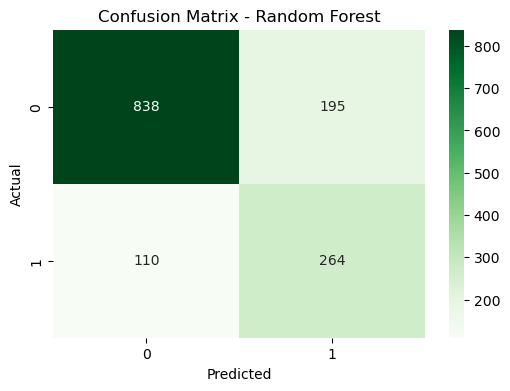

Saved model: RandomForest_BestModel.sav


In [38]:
# Random Forest with hyperparameter tuning, threshold optimization, evaluation, and saving

from sklearn.ensemble import RandomForestClassifier  # Random Forest classifier

# Define hyperparameter search space for Random Forest
rf_param_grid = {
    "n_estimators": [300],        # Number of trees
    "max_depth": [6, 10, None],   # Tree depth (None = full depth)
    "min_samples_split": [5],     # Minimum samples needed to split a node
    "min_samples_leaf": [2],      # Minimum samples required at a leaf node
    "bootstrap": [True]           # Use bootstrapped samples for each tree
}

# Perform GridSearchCV to find the best RF hyperparameters
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),  # Base model
    param_grid=rf_param_grid,                                      # Parameters to try
    scoring="roc_auc",                                             # Optimize based on ROC-AUC
    cv=5,                                                          # 5-fold cross-validation
    n_jobs=-1,                                                     # Use all CPU cores
    verbose=1                                                      # Show progress
)

# Train the model and record training time
start_rf = time.time()
rf_grid.fit(X_train, y_train)  # Fit GridSearch on training data
end_rf = time.time()

print("Best RF Params:", rf_grid.best_params_)  # Best hyperparameter combination
print("RF Training Time:", round(end_rf - start_rf, 3), "sec")  # Training duration

# Extract the best Random Forest model found by GridSearchCV
rf_best = rf_grid.best_estimator_

# Predict churn probabilities (needed for threshold tuning)
y_prob_rf = rf_best.predict_proba(X_test)[:, 1]  # Probability of class 1 (churn)

# Compute ROC curve values for later plotting/analysis
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)  # False positive rate and true positive rate

# Automatically find the threshold that gives the best F1-score
thresholds = np.arange(0.1, 0.91, 0.01)  # Test thresholds from 0.10 to 0.90

best_f1_rf = 0
best_threshold_rf = 0.5  # Default threshold

for t in thresholds:
    y_pred_t = (y_prob_rf >= t).astype(int)  # Convert probabilities to class labels using threshold t
    f1 = f1_score(y_test, y_pred_t)          # Compute F1-score
    if f1 > best_f1_rf:
        best_f1_rf = f1
        best_threshold_rf = t

print("Best Threshold (RF):", best_threshold_rf)  # Threshold with highest F1-score
print("Best F1 at Threshold:", best_f1_rf)        # Best F1-score achieved

# Make final predictions using the best threshold
y_pred_rf = (y_prob_rf >= best_threshold_rf).astype(int)  # Final churn predictions

# Print evaluation metrics for Random Forest
print("\n--- Random Forest Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))       # Overall correctness
print("Recall:", recall_score(y_test, y_pred_rf))           # Ability to catch churners
print("Precision:", precision_score(y_test, y_pred_rf))     # Correctness of churn predictions
print("F1 Score:", f1_score(y_test, y_pred_rf))             # Balance of precision and recall
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))         # Ranking quality using probabilities

# Show detailed classification metrics per class
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))  # Precision/recall/F1 for each class

# Plot confusion matrix to visualize prediction outcomes
cm = confusion_matrix(y_test, y_pred_rf)  # Compute confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")  # Heatmap display
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save the best trained Random Forest model to disk
joblib.dump(rf_best, "RandomForest_BestModel.sav")  # Save model file
print("Saved model: RandomForest_BestModel.sav")

# Store Random Forest results for later model comparison
model_results.append({
    "model": "Random Forest",                           # Model name
    "roc_auc": roc_auc_score(y_test, y_prob_rf),        # ROC-AUC score
    "accuracy": accuracy_score(y_test, y_pred_rf),      # Accuracy score
    "recall": recall_score(y_test, y_pred_rf),          # Recall score
    "precision": precision_score(y_test, y_pred_rf),    # Precision score
    "f1": f1_score(y_test, y_pred_rf),                  # F1-score
    "best_threshold": best_threshold_rf,                # Best threshold used
    "train_time_sec": round(end_rf - start_rf, 4),      # Training time in seconds
    "fpr": fpr_rf,                                      # ROC curve FPR values
    "tpr": tpr_rf                                       # ROC curve TPR values
})


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best XGBoost Params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}
XGBoost Training Time: 30.697 sec
Best Threshold (XGBoost): 0.3199999999999999
Best F1 at Threshold: 0.6365638766519823

--- XGBoost Evaluation ---
Accuracy: 0.7654584221748401
Recall: 0.7727272727272727
Precision: 0.5411985018726592
F1 Score: 0.6365638766519823
ROC-AUC: 0.8418434961769623

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.76      0.83      1033
           1       0.54      0.77      0.64       374

    accuracy                           0.77      1407
   macro avg       0.72      0.77      0.73      1407
weighted avg       0.81      0.77      0.78      1407



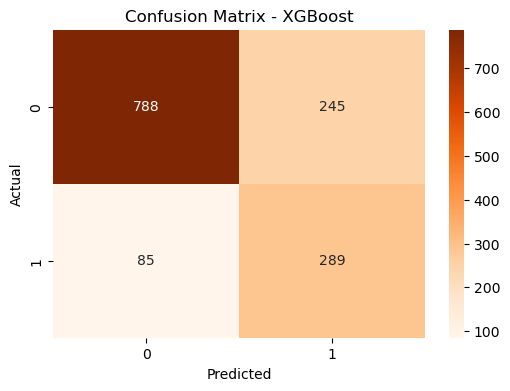

Saved model: XGBoost_BestModel.sav


In [39]:
# Define hyperparameter search space for XGBoost
xg_param_grid = {
    "n_estimators": [200, 300],         # Number of trees
    "max_depth": [4, 6, 8],             # Maximum tree depth
    "learning_rate": [0.01, 0.05, 0.1], # Step size for boosting
    "subsample": [0.8, 1.0],            # Row sampling ratio
    "colsample_bytree": [0.8, 1.0]      # Feature sampling ratio per tree
}

# Initialize base XGBoost model
xg_model = XGBClassifier(
    eval_metric="logloss",      # Evaluation metric during training
    use_label_encoder=False,    # Disable deprecated label encoder
    random_state=42,            # Reproducibility
    n_jobs=-1                   # Use all CPU cores
)

# Run GridSearchCV to find best XGBoost hyperparameters
xg_grid = GridSearchCV(
    estimator=xg_model,         # Model to tune
    param_grid=xg_param_grid,   # Parameters to try
    scoring="roc_auc",          # Optimize based on ROC-AUC
    cv=5,                       # 5-fold cross-validation
    n_jobs=-1,                  # Use all CPU cores
    verbose=1                   # Show progress
)

# Train the model and record training time
start_xg = time.time()
xg_grid.fit(X_train, y_train)   # Fit GridSearch on training data
end_xg = time.time()

print("Best XGBoost Params:", xg_grid.best_params_)  # Best hyperparameter combination
print("XGBoost Training Time:", round(end_xg - start_xg, 3), "sec")  # Training duration

# Extract the best XGBoost model found by GridSearchCV
xg_best = xg_grid.best_estimator_

# Predict churn probabilities (needed for threshold tuning)
y_prob_xg = xg_best.predict_proba(X_test)[:, 1]  # Probability of class 1 (churn)

# Compute ROC curve values for later plotting/analysis
fpr_xg, tpr_xg, _ = roc_curve(y_test, y_prob_xg)  # False positive rate and true positive rate

# Automatically find the threshold that gives the best F1-score
thresholds = np.arange(0.1, 0.91, 0.01)  # Test thresholds from 0.10 to 0.90

best_f1_xg = 0
best_threshold_xg = 0.5  # Default threshold

for t in thresholds:
    y_pred_t = (y_prob_xg >= t).astype(int)  # Convert probabilities to class labels using threshold t
    f1 = f1_score(y_test, y_pred_t)          # Compute F1-score
    if f1 > best_f1_xg:
        best_f1_xg = f1
        best_threshold_xg = t

print("Best Threshold (XGBoost):", best_threshold_xg)  # Threshold with highest F1-score
print("Best F1 at Threshold:", best_f1_xg)             # Best F1-score achieved

# Make final predictions using the best threshold
y_pred_xg = (y_prob_xg >= best_threshold_xg).astype(int)  # Final churn predictions

# Print evaluation metrics for XGBoost
print("\n--- XGBoost Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred_xg))       # Overall correctness
print("Recall:", recall_score(y_test, y_pred_xg))           # Ability to catch churners
print("Precision:", precision_score(y_test, y_pred_xg))     # Correctness of churn predictions
print("F1 Score:", f1_score(y_test, y_pred_xg))             # Balance of precision and recall
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xg))         # Ranking quality using probabilities

# Show detailed classification metrics per class
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xg))  # Precision/recall/F1 for each class

# Plot confusion matrix to visualize prediction outcomes
cm = confusion_matrix(y_test, y_pred_xg)  # Compute confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")  # Heatmap display
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Xg.jpg", dpi=300)  # Save confusion matrix plot
plt.show()

# Save the best trained XGBoost model to disk
joblib.dump(xg_best, "XGBoost_BestModel.sav")  # Save model file
print("Saved model: XGBoost_BestModel.sav")

# Store XGBoost results for later model comparison
model_results.append({
    "model": "XGBoost",                                 # Model name
    "roc_auc": roc_auc_score(y_test, y_prob_xg),         # ROC-AUC score
    "accuracy": accuracy_score(y_test, y_pred_xg),       # Accuracy score
    "recall": recall_score(y_test, y_pred_xg),           # Recall score
    "precision": precision_score(y_test, y_pred_xg),     # Precision score
    "f1": f1_score(y_test, y_pred_xg),                   # F1-score
    "best_threshold": best_threshold_xg,                 # Best threshold used
    "train_time_sec": round(end_xg - start_xg, 4),       # Training time in seconds
    "fpr": fpr_xg,                                       # ROC curve FPR values
    "tpr": tpr_xg                                        # ROC curve TPR values
})


Stacking Training Time: 8.068 sec
Best Threshold (Stacking): 0.3699999999999999
Best F1 (Stacking): 0.6330390920554855

--- STACKING ENSEMBLE Evaluation ---
Accuracy: 0.7931769722814499
Recall: 0.6711229946524064
Precision: 0.5990453460620525
F1 Score: 0.6330390920554855
ROC-AUC: 0.8423314058528454

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1033
           1       0.60      0.67      0.63       374

    accuracy                           0.79      1407
   macro avg       0.74      0.75      0.74      1407
weighted avg       0.80      0.79      0.80      1407



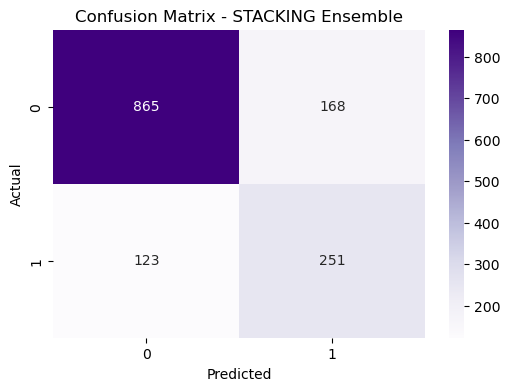

Saved model: StackingEnsemble_BestModel.sav


In [40]:
# Build a stacking ensemble using the best tuned base models, then tune threshold, evaluate, and save

# Define base (level-0) models for stacking
estimators = [
    ("lr", lr_best),   # Best Logistic Regression model
    ("rf", rf_best),   # Best Random Forest model
    ("xg", xg_best)    # Best XGBoost model
]

# Define the meta (level-1) model that learns from base model outputs
stack_model = StackingClassifier(
    estimators=estimators,                         # Base models
    final_estimator=LogisticRegression(max_iter=500),  # Meta-model
    stack_method="predict_proba",                  # Use probabilities from base models
    n_jobs=-1,                                     # Use all CPU cores
    passthrough=False                              # Do not add original features to meta-model
)

# Train stacking model and record training time
start_stack = time.time()
stack_model.fit(X_train, y_train)                  # Fit stacking model on training data
end_stack = time.time()

print("Stacking Training Time:", round(end_stack - start_stack, 3), "sec")  # Training duration

# Predict churn probabilities for threshold tuning
y_prob_stack = stack_model.predict_proba(X_test)[:, 1]  # Probability of class 1 (churn)

# Compute ROC curve values for later plotting/analysis
fpr_stack, tpr_stack, _ = roc_curve(y_test, y_prob_stack)  # False positive rate and true positive rate

# Automatically find the threshold that gives the best F1-score
thresholds = np.arange(0.1, 0.91, 0.01)  # Test thresholds from 0.10 to 0.90

best_f1_stack = 0
best_threshold_stack = 0.5  # Default threshold

for t in thresholds:
    y_pred_t = (y_prob_stack >= t).astype(int)  # Convert probabilities to class labels using threshold t
    f1 = f1_score(y_test, y_pred_t)             # Compute F1-score
    if f1 > best_f1_stack:
        best_f1_stack = f1
        best_threshold_stack = t

print("Best Threshold (Stacking):", best_threshold_stack)  # Threshold with highest F1-score
print("Best F1 (Stacking):", best_f1_stack)                # Best F1-score achieved

# Make final predictions using the best threshold
y_pred_stack = (y_prob_stack >= best_threshold_stack).astype(int)  # Final churn predictions

# Print evaluation metrics for the stacking ensemble
print("\n--- STACKING ENSEMBLE Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred_stack))       # Overall correctness
print("Recall:", recall_score(y_test, y_pred_stack))           # Ability to catch churners
print("Precision:", precision_score(y_test, y_pred_stack))     # Correctness of churn predictions
print("F1 Score:", f1_score(y_test, y_pred_stack))             # Balance of precision and recall
print("ROC-AUC:", roc_auc_score(y_test, y_prob_stack))         # Ranking quality using probabilities

# Show detailed classification metrics per class
print("\nClassification Report:")
print(classification_report(y_test, y_pred_stack))  # Precision/recall/F1 for each class

# Plot confusion matrix to visualize prediction outcomes
cm = confusion_matrix(y_test, y_pred_stack)  # Compute confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")  # Heatmap display
plt.title("Confusion Matrix - STACKING Ensemble")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save the trained stacking model to disk
joblib.dump(stack_model, "StackingEnsemble_BestModel.sav")  # Save model file
print("Saved model: StackingEnsemble_BestModel.sav")

# Store stacking results for later model comparison
model_results.append({
    "model": "Stacking Ensemble",                         # Model name
    "roc_auc": roc_auc_score(y_test, y_prob_stack),        # ROC-AUC score
    "accuracy": accuracy_score(y_test, y_pred_stack),      # Accuracy score
    "recall": recall_score(y_test, y_pred_stack),          # Recall score
    "precision": precision_score(y_test, y_pred_stack),    # Precision score
    "f1": f1_score(y_test, y_pred_stack),                  # F1-score
    "best_threshold": best_threshold_stack,                # Best threshold used
    "train_time_sec": round(end_stack - start_stack, 4),   # Training time in seconds
    "fpr": fpr_stack,                                      # ROC curve FPR values
    "tpr": tpr_stack                                       # ROC curve TPR values
})


In [41]:
# Convert stored model results into a DataFrame
results_df = pd.DataFrame(model_results)  # Create results table from model metrics

# Keep only key evaluation metrics
results_df = results_df[
    ["model", "roc_auc", "accuracy", "recall", "precision", "f1",
     "best_threshold", "train_time_sec"]
]

# Sort models by recall first, then ROC-AUC
results_sorted = results_df.sort_values(
    by=["recall", "roc_auc"], 
    ascending=[False, False]
).reset_index(drop=True)

print("Sorted Model Performance Table")
display(results_sorted)  # Display ranked model comparison

Sorted Model Performance Table


,model,roc_auc,accuracy,recall,precision,f1,best_threshold,train_time_sec
0,XGBoost,0.841843,0.765458,0.772727,0.541199,0.636564,0.32,30.6967
1,Random Forest,0.839089,0.783227,0.705882,0.575163,0.633854,0.36,7.6597
2,Stacking Ensemble,0.842331,0.793177,0.671123,0.599045,0.633039,0.37,8.0678
3,Logistic Regression,0.837118,0.795309,0.657754,0.605911,0.630769,0.43,1.5207


In [43]:
# Prepare numeric performance metrics for heatmap visualization
heatmap_df = results_df.set_index("model")[
    ["roc_auc", "accuracy", "recall", "precision", "f1"]
]


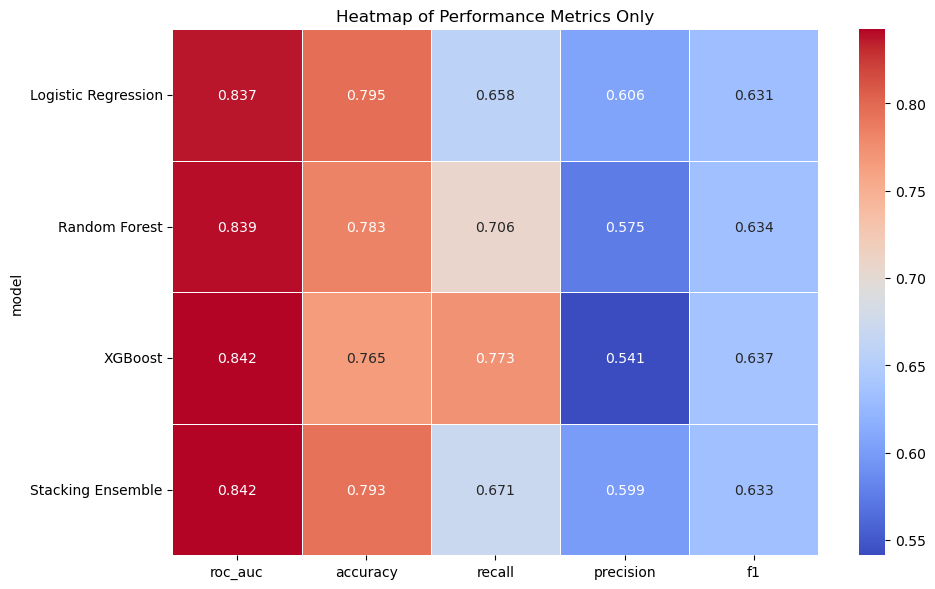

In [44]:
# Select performance metrics for visualization
heatmap_df_perf = heatmap_df[["roc_auc", "accuracy", "recall", "precision", "f1"]]

# Plot heatmap of model performance metrics
plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_df_perf,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Heatmap of Performance Metrics Only")
plt.tight_layout()
plt.show()


In [51]:
# Apply SMOTE-Tomek only on the training data to handle class imbalance
print("Original y_train class distribution:", Counter(y_train))  # Class distribution before resampling

smote_tomek = SMOTETomek(random_state=42)  # Initialize SMOTE-Tomek sampler
X_train_sm, y_train_sm = smote_tomek.fit_resample(X_train, y_train)  # Resample training data

print("After SMOTE-Tomek y_train class distribution:", Counter(y_train_sm))  # Distribution after resampling
print("Original X_train shape:", X_train.shape)          # Original training data shape
print("SMOTE-Tomek X_train_sm shape:", X_train_sm.shape) # Resampled training data shape

# Container to store model results after SMOTE-Tomek
model_results_smote = []


Original y_train class distribution: Counter({0: 4130, 1: 1495})
After SMOTE-Tomek y_train class distribution: Counter({0: 3888, 1: 3888})
Original X_train shape: (5625, 25)
SMOTE-Tomek X_train_sm shape: (7776, 25)


Class distribution before SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64


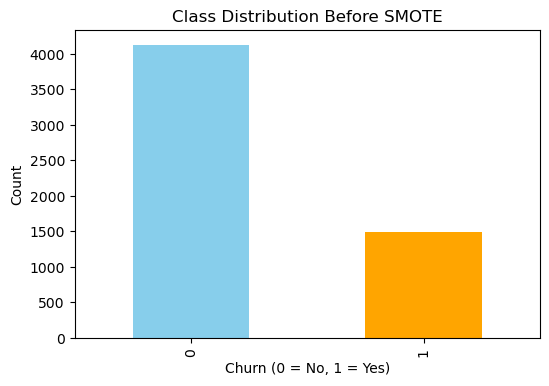

In [53]:
# Visualize class distribution before applying SMOTE
print("Class distribution before SMOTE:")
print(pd.Series(y_train).value_counts())  # Count samples per class

plt.figure(figsize=(6, 4))
pd.Series(y_train).value_counts().plot(kind='bar', color=['skyblue', 'orange'])  # Bar plot of class counts
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

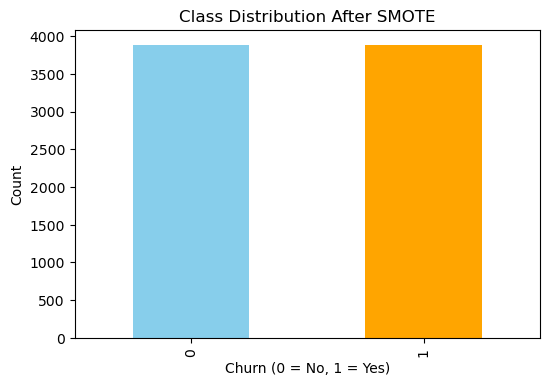

Saved: Smote.jpg


In [55]:
# Visualize class distribution after applying SMOTE-Tomek
plt.figure(figsize=(6, 4))
pd.Series(y_train_sm).value_counts().plot(kind='bar', color=['skyblue', 'orange'])  # Bar plot after resampling
plt.title("Class Distribution After SMOTE")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.savefig("Smote.jpg", dpi=300)  # Save plot as image
plt.show()

print("Saved: Smote.jpg")  # Confirm file save

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best LR Params (SMOTE): {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
LR Training Time (SMOTE): 5.065 sec
Best Threshold (LR SMOTE): 0.6399999999999997
Best F1 at Threshold (SMOTE): 0.6208588957055214

--- Logistic Regression (SMOTE) Evaluation ---
Accuracy: 0.7803837953091685
Recall: 0.6764705882352942
Precision: 0.5736961451247166
F1 Score: 0.6208588957055214
ROC-AUC: 0.8256984744086846

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1033
           1       0.57      0.68      0.62       374

    accuracy                           0.78      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.79      0.78      0.79      1407



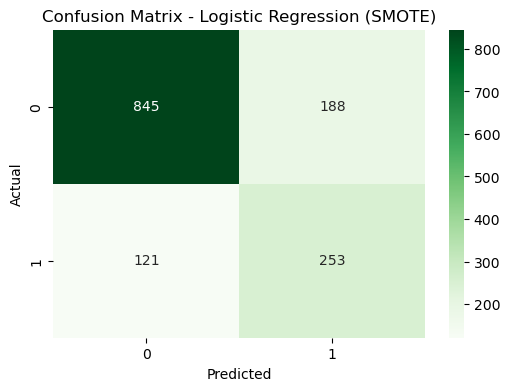

Saved model: LogisticRegression_SMOTE.sav


In [57]:
# Train Logistic Regression on SMOTE-Tomek resampled training data, tune threshold, evaluate on original test set, and save

# Define hyperparameter search space for Logistic Regression
lr_param_grid = {
    "penalty": ["l1", "l2"],        # Regularization type
    "C": [0.01, 0.1, 1, 10],        # Regularization strength (smaller C = stronger regularization)
    "solver": ["liblinear"]         # Solver that supports both L1 and L2
}

# Run GridSearchCV for Logistic Regression using SMOTE-resampled training data
lr_grid_sm = GridSearchCV(
    estimator=LogisticRegression(max_iter=500),  # Increase iterations to help convergence
    param_grid=lr_param_grid,                    # Parameters to try
    scoring="roc_auc",                           # Optimize based on ROC-AUC
    cv=5,                                        # 5-fold cross-validation
    n_jobs=-1,                                   # Use all CPU cores
    verbose=1                                    # Show progress
)

# Train the model and record training time (SMOTE data)
start_lr_sm = time.time()
lr_grid_sm.fit(X_train_sm, y_train_sm)           # Fit GridSearch on resampled training data
end_lr_sm = time.time()

print("Best LR Params (SMOTE):", lr_grid_sm.best_params_)  # Best hyperparameter combination
print("LR Training Time (SMOTE):", round(end_lr_sm - start_lr_sm, 3), "sec")  # Training duration

# Extract the best Logistic Regression model found by GridSearchCV
lr_best_sm = lr_grid_sm.best_estimator_

# Predict churn probabilities on the original (unchanged) test set
y_prob_lr_sm = lr_best_sm.predict_proba(X_test)[:, 1]  # Probability of class 1 (churn)

# Compute ROC curve values for later plotting/analysis
fpr_lr_sm, tpr_lr_sm, _ = roc_curve(y_test, y_prob_lr_sm)  # False positive rate and true positive rate

# Automatically find the threshold that gives the best F1-score on the test set
thresholds = np.arange(0.1, 0.91, 0.01)  # Test thresholds from 0.10 to 0.90

best_f1_sm = 0
best_threshold_lr_sm = 0.5  # Default threshold

for t in thresholds:
    y_pred_t = (y_prob_lr_sm >= t).astype(int)  # Convert probabilities to class labels using threshold t
    f1 = f1_score(y_test, y_pred_t)             # Compute F1-score
    if f1 > best_f1_sm:
        best_f1_sm = f1
        best_threshold_lr_sm = t

print("Best Threshold (LR SMOTE):", best_threshold_lr_sm)      # Threshold with highest F1-score
print("Best F1 at Threshold (SMOTE):", best_f1_sm)             # Best F1-score achieved

# Make final predictions using the best threshold
y_pred_lr_sm = (y_prob_lr_sm >= best_threshold_lr_sm).astype(int)  # Final churn predictions

# Print evaluation metrics for Logistic Regression (SMOTE)
print("\n--- Logistic Regression (SMOTE) Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_sm))          # Overall correctness
print("Recall:", recall_score(y_test, y_pred_lr_sm))              # Ability to catch churners
print("Precision:", precision_score(y_test, y_pred_lr_sm))        # Correctness of churn predictions
print("F1 Score:", f1_score(y_test, y_pred_lr_sm))                # Balance of precision and recall
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr_sm))            # Ranking quality using probabilities

# Show detailed classification metrics per class
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_sm))  # Precision/recall/F1 for each class

# Plot confusion matrix to visualize prediction outcomes
cm = confusion_matrix(y_test, y_pred_lr_sm)  # Compute confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")  # Heatmap display
plt.title("Confusion Matrix - Logistic Regression (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save the best trained Logistic Regression (SMOTE) model to disk
joblib.dump(lr_best_sm, "LogisticRegression_SMOTE.sav")  # Save model file
print("Saved model: LogisticRegression_SMOTE.sav")

# Store SMOTE Logistic Regression results for later comparison
model_results_smote.append({
    "model": "Logistic Regression (SMOTE)",                # Model name
    "roc_auc": roc_auc_score(y_test, y_prob_lr_sm),        # ROC-AUC score
    "accuracy": accuracy_score(y_test, y_pred_lr_sm),      # Accuracy score
    "recall": recall_score(y_test, y_pred_lr_sm),          # Recall score
    "precision": precision_score(y_test, y_pred_lr_sm),    # Precision score
    "f1": f1_score(y_test, y_pred_lr_sm),                  # F1-score
    "best_threshold": best_threshold_lr_sm,                # Best threshold used
    "train_time_sec": round(end_lr_sm - start_lr_sm, 4),   # Training time in seconds
    "fpr": fpr_lr_sm,                                      # ROC curve FPR values
    "tpr": tpr_lr_sm                                       # ROC curve TPR values
})


Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best RF Params (SMOTE): {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
RF Training Time (SMOTE): 21.845 sec
Best Threshold (RF SMOTE): 0.48999999999999977
Best F1 at Threshold (SMOTE): 0.6234906695938529

--- Random Forest (SMOTE) Evaluation ---
Accuracy: 0.7562189054726368
Recall: 0.7593582887700535
Precision: 0.5288640595903166
F1 Score: 0.6234906695938529
ROC-AUC: 0.8316142174550011

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1033
           1       0.53      0.76      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.76      0.77      1407



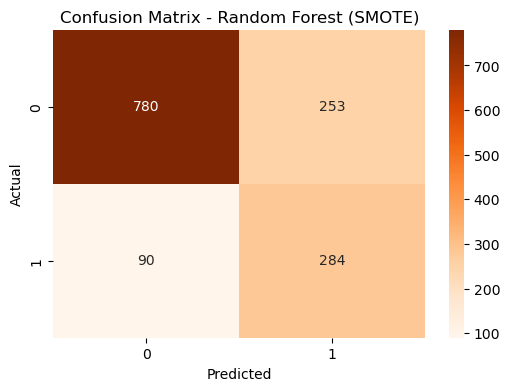

Saved model: RandomForest_SMOTE.sav


In [59]:
# Train Random Forest on SMOTE-Tomek resampled training data, tune threshold, evaluate on original test set, and save

# Define hyperparameter search space for Random Forest
rf_param_grid = {
    "n_estimators": [200, 300, 400],  # Number of trees
    "max_depth": [6, 8, 10],          # Maximum tree depth
    "min_samples_split": [5],         # Minimum samples needed to split a node
    "min_samples_leaf": [2]           # Minimum samples required at a leaf node
}

# Run GridSearchCV for Random Forest using SMOTE-resampled training data
rf_grid_sm = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),  # Base model
    param_grid=rf_param_grid,                                      # Parameters to try
    scoring="roc_auc",                                             # Optimize based on ROC-AUC
    cv=5,                                                          # 5-fold cross-validation
    n_jobs=-1,                                                     # Use all CPU cores
    verbose=1                                                      # Show progress
)

# Train the model and record training time (SMOTE data)
start_rf_sm = time.time()
rf_grid_sm.fit(X_train_sm, y_train_sm)                             # Fit GridSearch on resampled training data
end_rf_sm = time.time()

print("Best RF Params (SMOTE):", rf_grid_sm.best_params_)          # Best hyperparameter combination
print("RF Training Time (SMOTE):", round(end_rf_sm - start_rf_sm, 3), "sec")  # Training duration

# Extract the best Random Forest model found by GridSearchCV
rf_best_sm = rf_grid_sm.best_estimator_

# Predict churn probabilities on the original (unchanged) test set
y_prob_rf_sm = rf_best_sm.predict_proba(X_test)[:, 1]              # Probability of class 1 (churn)

# Compute ROC curve values for later plotting/analysis
fpr_rf_sm, tpr_rf_sm, _ = roc_curve(y_test, y_prob_rf_sm)          # False positive rate and true positive rate

# Automatically find the threshold that gives the best F1-score on the test set
thresholds = np.arange(0.1, 0.91, 0.01)                            # Test thresholds from 0.10 to 0.90

best_f1_rf_sm = 0
best_threshold_rf_sm = 0.5                                         # Default threshold

for t in thresholds:
    y_pred_t = (y_prob_rf_sm >= t).astype(int)                     # Convert probabilities to class labels using threshold t
    f1 = f1_score(y_test, y_pred_t)                                # Compute F1-score
    if f1 > best_f1_rf_sm:
        best_f1_rf_sm = f1
        best_threshold_rf_sm = t

print("Best Threshold (RF SMOTE):", best_threshold_rf_sm)          # Threshold with highest F1-score
print("Best F1 at Threshold (SMOTE):", best_f1_rf_sm)              # Best F1-score achieved

# Make final predictions using the best threshold
y_pred_rf_sm = (y_prob_rf_sm >= best_threshold_rf_sm).astype(int)  # Final churn predictions

# Print evaluation metrics for Random Forest (SMOTE)
print("\n--- Random Forest (SMOTE) Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_sm))           # Overall correctness
print("Recall:", recall_score(y_test, y_pred_rf_sm))               # Ability to catch churners
print("Precision:", precision_score(y_test, y_pred_rf_sm))         # Correctness of churn predictions
print("F1 Score:", f1_score(y_test, y_pred_rf_sm))                 # Balance of precision and recall
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_sm))             # Ranking quality using probabilities

# Show detailed classification metrics per class
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_sm))                 # Precision/recall/F1 for each class

# Plot confusion matrix to visualize prediction outcomes
cm = confusion_matrix(y_test, y_pred_rf_sm)                        # Compute confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")               # Heatmap display
plt.title("Confusion Matrix - Random Forest (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save the best trained Random Forest (SMOTE) model to disk
joblib.dump(rf_best_sm, "RandomForest_SMOTE.sav")                  # Save model file
print("Saved model: RandomForest_SMOTE.sav")

# Store SMOTE Random Forest results for later comparison
model_results_smote.append({
    "model": "Random Forest (SMOTE)",                              # Model name
    "roc_auc": roc_auc_score(y_test, y_prob_rf_sm),                # ROC-AUC score
    "accuracy": accuracy_score(y_test, y_pred_rf_sm),              # Accuracy score
    "recall": recall_score(y_test, y_pred_rf_sm),                  # Recall score
    "precision": precision_score(y_test, y_pred_rf_sm),            # Precision score
    "f1": f1_score(y_test, y_pred_rf_sm),                          # F1-score
    "best_threshold": best_threshold_rf_sm,                        # Best threshold used
    "train_time_sec": round(end_rf_sm - start_rf_sm, 4),           # Training time in seconds
    "fpr": fpr_rf_sm,                                              # ROC curve FPR values
    "tpr": tpr_rf_sm                                               # ROC curve TPR values
})


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best XGBoost Params (SMOTE): {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300, 'subsample': 1.0}
XGBoost Training Time (SMOTE): 35.902 sec
Best Threshold (XGBoost SMOTE): 0.32999999999999985
Best F1 at Threshold (SMOTE): 0.6114101184068891

--- XGBoost (SMOTE) Evaluation ---
Accuracy: 0.7434257285003554
Recall: 0.7593582887700535
Precision: 0.5117117117117117
F1 Score: 0.6114101184068891
ROC-AUC: 0.8125507969622769

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1033
           1       0.51      0.76      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.76      1407



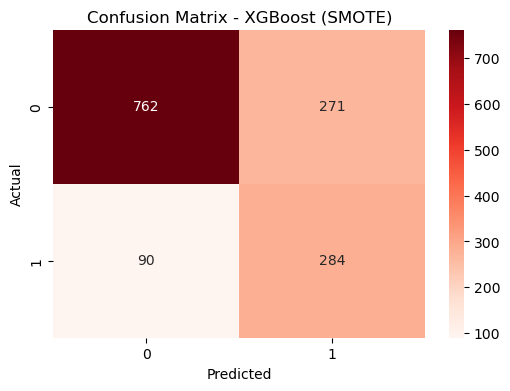

Saved model: XGBoost_SMOTE.sav


In [61]:
# Train XGBoost on SMOTE-Tomek resampled training data, tune threshold, evaluate on original test set, and save

# Define hyperparameter search space for XGBoost
xg_param_grid = {
    "n_estimators": [200, 300],         # Number of trees
    "max_depth": [4, 6, 8],             # Maximum tree depth
    "learning_rate": [0.01, 0.05, 0.1], # Step size for boosting
    "subsample": [0.8, 1.0],            # Row sampling ratio
    "colsample_bytree": [0.8, 1.0]      # Feature sampling ratio per tree
}

# Initialize base XGBoost model (for SMOTE training data)
xg_model_sm = XGBClassifier(
    eval_metric="logloss",      # Evaluation metric during training
    use_label_encoder=False,    # Disable deprecated label encoder
    random_state=42,            # Reproducibility
    n_jobs=-1                   # Use all CPU cores
)

# Run GridSearchCV for XGBoost using SMOTE-resampled training data
xg_grid_sm = GridSearchCV(
    estimator=xg_model_sm,      # Model to tune
    param_grid=xg_param_grid,   # Parameters to try
    scoring="roc_auc",          # Optimize based on ROC-AUC
    cv=5,                       # 5-fold cross-validation
    n_jobs=-1,                  # Use all CPU cores
    verbose=1                   # Show progress
)

# Train the model and record training time (SMOTE data)
start_xg_sm = time.time()
xg_grid_sm.fit(X_train_sm, y_train_sm)  # Fit GridSearch on resampled training data
end_xg_sm = time.time()

print("Best XGBoost Params (SMOTE):", xg_grid_sm.best_params_)  # Best hyperparameter combination
print("XGBoost Training Time (SMOTE):", round(end_xg_sm - start_xg_sm, 3), "sec")  # Training duration

# Extract the best XGBoost model found by GridSearchCV
xg_best_sm = xg_grid_sm.best_estimator_

# Predict churn probabilities on the original (unchanged) test set
y_prob_xg_sm = xg_best_sm.predict_proba(X_test)[:, 1]  # Probability of class 1 (churn)

# Compute ROC curve values for later plotting/analysis
fpr_xg_sm, tpr_xg_sm, _ = roc_curve(y_test, y_prob_xg_sm)  # False positive rate and true positive rate

# Automatically find the threshold that gives the best F1-score on the test set
thresholds = np.arange(0.1, 0.91, 0.01)  # Test thresholds from 0.10 to 0.90

best_f1_xg_sm = 0
best_threshold_xg_sm = 0.5  # Default threshold

for t in thresholds:
    y_pred_t = (y_prob_xg_sm >= t).astype(int)  # Convert probabilities to class labels using threshold t
    f1 = f1_score(y_test, y_pred_t)             # Compute F1-score
    if f1 > best_f1_xg_sm:
        best_f1_xg_sm = f1
        best_threshold_xg_sm = t

print("Best Threshold (XGBoost SMOTE):", best_threshold_xg_sm)  # Threshold with highest F1-score
print("Best F1 at Threshold (SMOTE):", best_f1_xg_sm)           # Best F1-score achieved

# Make final predictions using the best threshold
y_pred_xg_sm = (y_prob_xg_sm >= best_threshold_xg_sm).astype(int)  # Final churn predictions

# Print evaluation metrics for XGBoost (SMOTE)
print("\n--- XGBoost (SMOTE) Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred_xg_sm))          # Overall correctness
print("Recall:", recall_score(y_test, y_pred_xg_sm))              # Ability to catch churners
print("Precision:", precision_score(y_test, y_pred_xg_sm))        # Correctness of churn predictions
print("F1 Score:", f1_score(y_test, y_pred_xg_sm))                # Balance of precision and recall
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xg_sm))            # Ranking quality using probabilities

# Show detailed classification metrics per class
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xg_sm))                # Precision/recall/F1 for each class

# Plot confusion matrix to visualize prediction outcomes
cm = confusion_matrix(y_test, y_pred_xg_sm)                       # Compute confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")                 # Heatmap display
plt.title("Confusion Matrix - XGBoost (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save the best trained XGBoost (SMOTE) model to disk
joblib.dump(xg_best_sm, "XGBoost_SMOTE.sav")                      # Save model file
print("Saved model: XGBoost_SMOTE.sav")

# Store SMOTE XGBoost results for later comparison
model_results_smote.append({
    "model": "XGBoost (SMOTE)",                                   # Model name
    "roc_auc": roc_auc_score(y_test, y_prob_xg_sm),               # ROC-AUC score
    "accuracy": accuracy_score(y_test, y_pred_xg_sm),             # Accuracy score
    "recall": recall_score(y_test, y_pred_xg_sm),                 # Recall score
    "precision": precision_score(y_test, y_pred_xg_sm),           # Precision score
    "f1": f1_score(y_test, y_pred_xg_sm),                         # F1-score
    "best_threshold": best_threshold_xg_sm,                       # Best threshold used
    "train_time_sec": round(end_xg_sm - start_xg_sm, 4),          # Training time in seconds
    "fpr": fpr_xg_sm,                                             # ROC curve FPR values
    "tpr": tpr_xg_sm                                              # ROC curve TPR values
})


Training Time (BEST Stacking SMOTE): 7.514 seconds
Optimal Threshold (BEST Stacking SMOTE): 0.2899999999999999
Best F1 Score (SMOTE): 0.614406779661017

BEST STACKING SMOTE MODEL PERFORMANCE
Accuracy: 0.7412935323383084
Recall: 0.7754010695187166
Precision: 0.5087719298245614
F1 Score: 0.614406779661017
ROC-AUC: 0.8249789047010161

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1033
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407



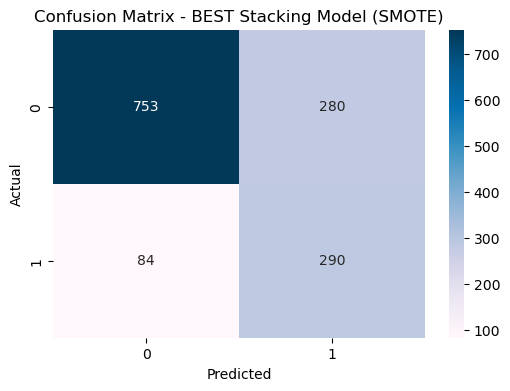

Saved best model as: BEST_Stacking_SMOTE.sav


In [63]:
# Define base models (best models trained on SMOTE data)
estimators_best_sm = [
    ("lr", lr_best_sm),     # Best Logistic Regression (SMOTE)
    ("rf", rf_best_sm),     # Best Random Forest (SMOTE)
    ("xg", xg_best_sm)      # Best XGBoost (SMOTE)
]

# Define meta-learner (final model) for stacking
meta_model_sm = LogisticRegression(max_iter=500)  # Meta-model to combine base predictions

# Build stacking ensemble model
stack_best_sm = StackingClassifier(
    estimators=estimators_best_sm,     # Base models
    final_estimator=meta_model_sm,     # Meta-model
    stack_method="predict_proba",      # Use probability outputs from base models
    passthrough=False,                # Do not include original features in meta-model
    n_jobs=-1                          # Use all CPU cores
)

# Train stacking ensemble on SMOTE-resampled training data
start_stack_best = time.time()
stack_best_sm.fit(X_train_sm, y_train_sm)  # Fit stacking model on resampled training data
end_stack_best = time.time()

print("Training Time (BEST Stacking SMOTE):", round(end_stack_best - start_stack_best, 3), "seconds")  # Training duration

# Predict churn probabilities on the original (unchanged) test set
y_prob_stack_best = stack_best_sm.predict_proba(X_test)[:, 1]  # Probability of class 1 (churn)

# Compute ROC curve values for later plotting/analysis
fpr_stack_best, tpr_stack_best, _ = roc_curve(y_test, y_prob_stack_best)  # False positive rate and true positive rate

# Automatically find the threshold that gives the best F1-score on the test set
thresholds = np.arange(0.1, 0.91, 0.01)  # Test thresholds from 0.10 to 0.90

best_f1_stack_best = 0
best_threshold_stack_best = 0.5  # Default threshold

for t in thresholds:
    y_pred_t = (y_prob_stack_best >= t).astype(int)  # Convert probabilities to class labels using threshold t
    f1 = f1_score(y_test, y_pred_t)                  # Compute F1-score
    if f1 > best_f1_stack_best:
        best_f1_stack_best = f1
        best_threshold_stack_best = t

print("Optimal Threshold (BEST Stacking SMOTE):", best_threshold_stack_best)  # Threshold with highest F1-score
print("Best F1 Score (SMOTE):", best_f1_stack_best)                           # Best F1-score achieved

# Make final predictions using the best threshold
y_pred_stack_best = (y_prob_stack_best >= best_threshold_stack_best).astype(int)  # Final churn predictions

# Print evaluation metrics for the best stacking SMOTE model
print("\nBEST STACKING SMOTE MODEL PERFORMANCE")
print("Accuracy:", accuracy_score(y_test, y_pred_stack_best))       # Overall correctness
print("Recall:", recall_score(y_test, y_pred_stack_best))           # Ability to catch churners
print("Precision:", precision_score(y_test, y_pred_stack_best))     # Correctness of churn predictions
print("F1 Score:", f1_score(y_test, y_pred_stack_best))             # Balance of precision and recall
print("ROC-AUC:", roc_auc_score(y_test, y_prob_stack_best))         # Ranking quality using probabilities

# Show detailed classification metrics per class
print("\nClassification Report:")
print(classification_report(y_test, y_pred_stack_best))  # Precision/recall/F1 for each class

# Plot confusion matrix to visualize prediction outcomes
cm = confusion_matrix(y_test, y_pred_stack_best)  # Compute confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuBu")  # Heatmap display
plt.title("Confusion Matrix - BEST Stacking Model (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Smote stacking.jpg", dpi=300)  # Save confusion matrix plot
plt.show()

# Save the trained best stacking SMOTE model to disk
joblib.dump(stack_best_sm, "BEST_Stacking_SMOTE.sav")  # Save model file
print("Saved best model as: BEST_Stacking_SMOTE.sav")

# Store best stacking SMOTE results for later comparison
model_results_smote.append({
    "model": "BEST Stacking (SMOTE)",                         # Model name
    "roc_auc": roc_auc_score(y_test, y_prob_stack_best),      # ROC-AUC score
    "accuracy": accuracy_score(y_test, y_pred_stack_best),    # Accuracy score
    "recall": recall_score(y_test, y_pred_stack_best),        # Recall score
    "precision": precision_score(y_test, y_pred_stack_best),  # Precision score
    "f1": f1_score(y_test, y_pred_stack_best),                # F1-score
    "best_threshold": best_threshold_stack_best,              # Best threshold used
    "train_time_sec": round(end_stack_best - start_stack_best, 4),  # Training time in seconds
    "fpr": fpr_stack_best,                                    # ROC curve FPR values
    "tpr": tpr_stack_best                                     # ROC curve TPR values
})


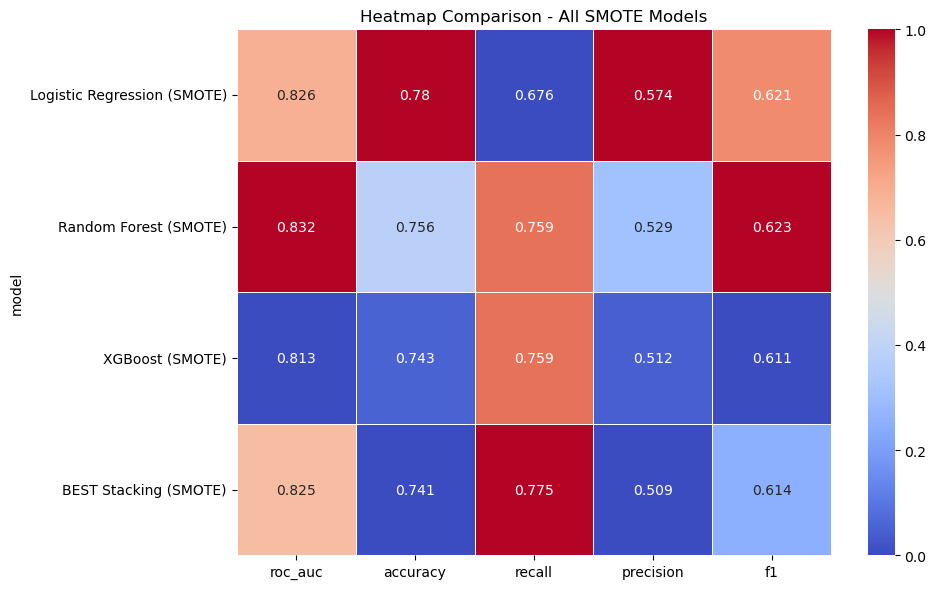

In [65]:
# Create a heatmap to compare performance metrics across all SMOTE-trained models

results_smote_df = pd.DataFrame(model_results_smote)  # Convert SMOTE model results into a DataFrame

# Select key performance metrics for the heatmap
heatmap_smote = results_smote_df.set_index("model")[
    ["roc_auc", "accuracy", "recall", "precision", "f1"]
]

# Normalize values to 0–1 range to improve heatmap color contrast
heatmap_smote_norm = (heatmap_smote - heatmap_smote.min()) / (heatmap_smote.max() - heatmap_smote.min())

# Plot normalized heatmap while displaying original metric values as annotations
plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_smote_norm,                 # Normalized values control the colors
    annot=heatmap_smote.round(3),       # Show original metric values on the heatmap
    fmt="",                             # Keep annotation formatting as provided
    cmap="coolwarm",                    # Color scheme
    linewidths=0.5                      # Add grid lines
)

plt.title("Heatmap Comparison - All SMOTE Models")  # Heatmap title
plt.tight_layout()
plt.savefig("Heatmap Comparison - All SMOTE Models.jpg")  # Save heatmap image
plt.show()


In [67]:
# Convert stored model results into DataFrames
df_normal = pd.DataFrame(model_results)          # Results from models trained on original data
df_smote = pd.DataFrame(model_results_smote)     # Results from models trained with SMOTE

# Add labels to distinguish training strategy
df_normal["type"] = "Normal"                     # Models trained without resampling
df_smote["type"] = "SMOTE"                       # Models trained with SMOTE

# Combine normal and SMOTE results into one table
df_all = pd.concat([df_normal, df_smote], ignore_index=True)

# Select key metrics for comparison
df_all = df_all[
    ["model", "type", "roc_auc", "accuracy", "recall", "precision", "f1",
     "best_threshold", "train_time_sec"]
]

# Rank models for churn prediction (priority: Recall > ROC-AUC > F1)
df_ranked = df_all.sort_values(
    by=["recall", "roc_auc", "f1"],
    ascending=[False, False, False]
).reset_index(drop=True)

# Display final ranked comparison table
df_ranked


,model,type,roc_auc,accuracy,recall,precision,f1,best_threshold,train_time_sec
0,BEST Stacking (SMOTE),SMOTE,0.824979,0.741294,0.775401,0.508772,0.614407,0.29,7.5140
1,XGBoost,Normal,0.841843,0.765458,0.772727,0.541199,0.636564,0.32,30.6967
2,Random Forest (SMOTE),SMOTE,0.831614,0.756219,0.759358,0.528864,0.623491,0.49,21.8453
3,XGBoost (SMOTE),SMOTE,0.812551,0.743426,0.759358,0.511712,0.611410,0.33,35.9016
4,Random Forest,Normal,0.839089,0.783227,0.705882,0.575163,0.633854,0.36,7.6597
5,Logistic Regression (SMOTE),SMOTE,0.825698,0.780384,0.676471,0.573696,0.620859,0.64,5.0647
6,Stacking Ensemble,Normal,0.842331,0.793177,0.671123,0.599045,0.633039,0.37,8.0678
7,Logistic Regression,Normal,0.837118,0.795309,0.657754,0.605911,0.630769,0.43,1.5207


Top 3 Models:
 - XGBoost (Normal)
 - BEST Stacking (SMOTE) (SMOTE)
 - Random Forest (SMOTE) (SMOTE)


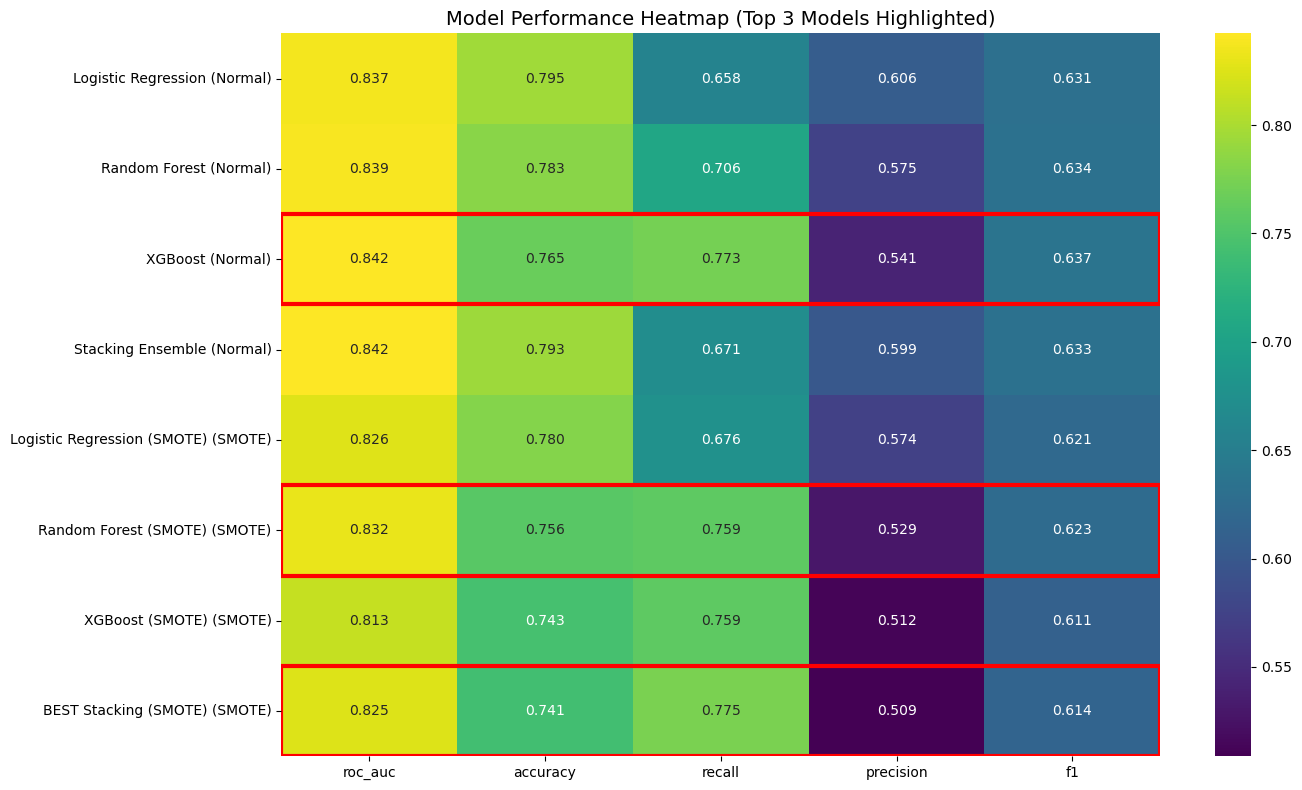

Saved: top3_models_heatmap.jpg


In [69]:
# Combine results from normal and SMOTE models into one DataFrame
df_normal = pd.DataFrame(model_results)             # Results from models trained on original data
df_smote = pd.DataFrame(model_results_smote)        # Results from models trained with SMOTE

# Add labels to identify training approach
df_normal["type"] = "Normal"                        # No resampling
df_smote["type"] = "SMOTE"                          # SMOTE-Tomek resampling

# Merge both result tables
df_all = pd.concat([df_normal, df_smote], ignore_index=True)

# Define metrics to visualize in the heatmap
metric_cols = ["roc_auc", "accuracy", "recall", "precision", "f1"]

# Build heatmap data and set row labels as "Model (Type)"
df_heatmap = df_all[metric_cols].copy()             # Keep only metric columns
df_heatmap.index = df_all["model"] + " (" + df_all["type"] + ")"  # Create readable row names

# Create a combined score to rank models (prioritize recall more than ROC-AUC)
df_all["score_combo"] = df_all["recall"] * 0.6 + df_all["roc_auc"] * 0.4  # Weighted score

# Select the top 3 models based on the combined score
top3 = df_all.sort_values("score_combo", ascending=False).head(3)  # Top 3 models

# Create labels matching the heatmap index
top3_labels = (top3["model"] + " (" + top3["type"] + ")").tolist()  # Top 3 row labels

# Print the top 3 model names
print("Top 3 Models:")
for m in top3_labels:
    print(" -", m)

# Plot heatmap for all models and metrics
plt.figure(figsize=(14, 8))
ax = sns.heatmap(df_heatmap, annot=True, cmap="viridis", fmt=".3f")  # Heatmap with values

# Highlight the top 3 rows using red rectangle borders
for label in top3_labels:
    y_index = list(df_heatmap.index).index(label)  # Find row position in heatmap

    ax.add_patch(plt.Rectangle(
        (0, y_index),               # Bottom-left corner of the rectangle
        len(metric_cols),           # Width spans all metric columns
        1,                          # Height spans one row
        fill=False,                 # Outline only
        edgecolor="red",            # Red border
        linewidth=3                 # Border thickness
    ))

# Add title and adjust spacing
plt.title("Model Performance Heatmap (Top 3 Models Highlighted)", fontsize=14)
plt.tight_layout()

# Save heatmap image as JPG
plt.savefig("top3_models_heatmap.jpg", dpi=300)     # Save high-quality image
plt.show()

print("Saved: top3_models_heatmap.jpg")              # Confirm file save
